# Proyecto: Detección de Matrículas Vehiculares con Visión por Computadora

In [1]:
# Instalación de dependencias en Google Colab

!pip install ultralytics easyocr
!apt install tesseract-ocr -y
!apt install libtesseract-dev -y
!pip install pytesseract
!pip install opencv-python
!pip install roboflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.8/963.8 kB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.1/292.1 kB 14.0 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libarchive-dev libleptonica-dev
The following NEW packages will be installed:
  libarchive-dev libleptonica-dev libtesseract-dev
0 upgraded, 3 newly installed, 0 to remove and 38 not upgraded.
Need to get 3,743 kB of archives.


Este notebook implementa un pipeline completo de detección de vehículos, detección de matrículas y reconocimiento de texto (OCR) desde un video. El flujo general incluye:

1. **Detección de vehículos** con un modelo YOLOv10 preentrenado (COCO).
2. **Detección de matrículas** con un modelo YOLOv8 entrenado en un dataset de matrículas (e.g., RoboFlow).
3. **OCR** con Tesseract para leer los caracteres de las matrículas.
4. **Procesamiento frame a frame de un video**, generando un nuevo video con etiquetas.


In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="dSMfDD4uPaMCKEoGOP5q")
project = rf.workspace("cicatriz").project("placa-de-carro-sxy3a")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to placa-de-carro-1 in yolov8:: 100%|██████████| 40/40 [00:00<00:00, 3743.08it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
rf = Roboflow(api_key="dSMfDD4uPaMCKEoGOP5q")
project = rf.workspace("put-poznan-6aps1").project("car_detect-chuwy")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to car_detect-1 in yolov8:: 100%|██████████| 1206/1206 [00:00<00:00, 4357.22it/s]


In [4]:
!wget https://github.com/adiacla/bigdata/raw/refs/heads/master/WhatsApp%20Video%202025-05-30%20at%2010.33.18%20AM.mp4

!wget https://github.com/adiacla/bigdata/raw/refs/heads/master/WhatsApp%20Video%202025-05-30%20at%2012.23.55%20PM.mp4

--2025-10-21 16:38:13--  https://github.com/adiacla/bigdata/raw/refs/heads/master/WhatsApp%20Video%202025-05-30%20at%2010.33.18%20AM.mp4
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/WhatsApp%20Video%202025-05-30%20at%2010.33.18%20AM.mp4 [following]
--2025-10-21 16:38:14--  https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/WhatsApp%20Video%202025-05-30%20at%2010.33.18%20AM.mp4
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7410227 (7.1M) [application/octet-stream]
Saving to: ‘WhatsApp Video 2025-05-30 at 10.33.18 AM.mp4’

WhatsApp Video 

In [5]:
# copie todas las imagenes /content/placa-de-carro-1/train/images a /content/car_detect-1/train/images

!cp /content/placa-de-carro-1/train/images/* /content/car_detect-1/train/images/

In [13]:
# copie todas las etiquetas de /content/placa-de-carro-1/train/labels a /content/car_detect-1/train/labels

!cp /content/placa-de-carro-1/train/labels/* /content/car_detect-1/train/labels/

In [7]:
import cv2
import pytesseract
import easyocr
from ultralytics import YOLO
import numpy as np
import os

# Configura el path si usas pytesseract local
# pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'


In [8]:
# Modelo 1: YOLOv10 preentrenado en COCO para detectar vehículos
modelo_vehiculo = YOLO('yolov8n.pt')  # Usamos YOLOv8n como placeholder para YOLOv10

# Cargar modelo base YOLOv8 nano
model = YOLO('yolov8n.pt')

# Entrenar el modelo con tu dataset
model.train(data='/content/car_detect-1/data.yaml', epochs=25, imgsz=640)



Ultralytics 8.3.218 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/car_detect-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pos

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cc6e1c5e0f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete
0: 640x640 1 pl_license_plate, 8.9ms
Speed: 2.1ms preprocess, 8.9ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)
📌 Texto detectado: MKI_47G


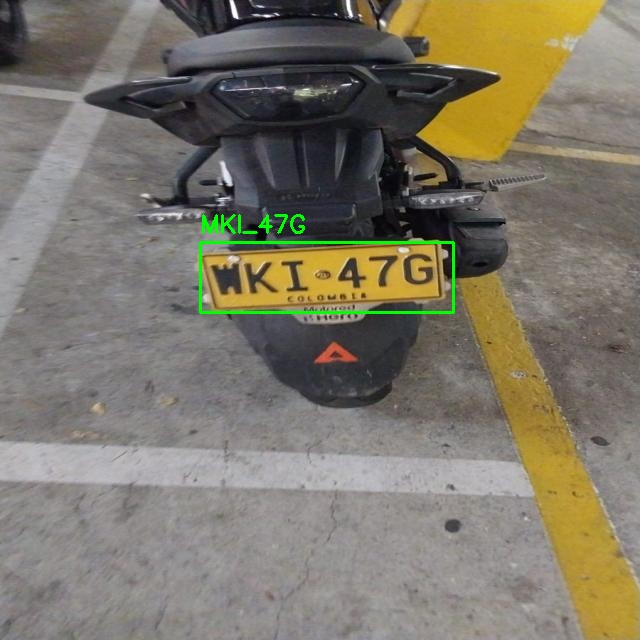

In [9]:
from IPython.display import display, Image
import os
import cv2
from ultralytics import YOLO
import numpy as np
import easyocr
from PIL import Image as PILImage

# Inicializar lector OCR
reader = easyocr.Reader(['en'])

# Cargar el modelo entrenado
trained_model = YOLO('/content/runs/detect/train/weights/best.pt')

# Ruta a una imagen de prueba
test_image = '/content/placa-de-carro-1/train/images/WhatsApp-Image-2025-05-30-at-10_30_01-AM_jpeg.rf.1df62f15936b5b83571dcaa7ed0911d1.jpg'

if not os.path.exists(test_image):
    print(f"Error: Imagen de prueba no encontrada en {test_image}")
else:
    image = cv2.imread(test_image)
    results = trained_model(image)[0]

    for r in results.boxes.data:
        x1, y1, x2, y2, conf, cls = r.cpu().numpy().astype(int)
        placa_img = image[y1:y2, x1:x2]

        # Preprocesamiento (opcional, EasyOCR es robusto)
        gris = cv2.cvtColor(placa_img, cv2.COLOR_BGR2GRAY)
        _, binarizada = cv2.threshold(gris, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # OCR con EasyOCR
        resultados_ocr = reader.readtext(binarizada)

        if resultados_ocr:
            texto_detectado = resultados_ocr[0][1].upper()  # Tomar solo el primer texto reconocido y ponerlo en mayúsculas
            print("📌 Texto detectado:", texto_detectado)

            # Dibujar texto sobre la imagen original
            cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.putText(image, texto_detectado, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)
        else:
            print("⚠️ No se detectó texto.")

    salida_path = 'resultado_placa.jpg'
    cv2.imwrite(salida_path, image)
    display(Image(filename=salida_path))



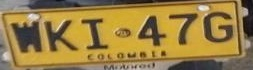

Texto detectado por OCR:
- Texto: CKI_47G (confianza: 0.23)
- Texto: L (confianza: 0.05)


In [10]:
# ================================
# PASO 5: OCR sobre la matrícula detectada
# ================================
import easyocr
import cv2
from PIL import Image as PILImage

# Inicializar lector OCR
reader = easyocr.Reader(['en'])

# Cargar imagen original y resultados
img = cv2.imread(test_image)

# Obtener las coordenadas del bounding box
for r in results:
    for box in r.boxes:
        xyxy = box.xyxy[0].cpu().numpy().astype(int)  # coordenadas
        x1, y1, x2, y2 = xyxy

        # Recortar la región de la matrícula
        plate_crop = img[y1:y2, x1:x2]

        # Guardar y mostrar la región
        cv2.imwrite("plate_crop.jpg", plate_crop)
        display(Image("plate_crop.jpg"))

        # OCR
        result = reader.readtext(plate_crop)
        print("Texto detectado por OCR:")
        for (bbox, text, confidence) in result:
            print(f"- Texto: {text.upper()} (confianza: {confidence:.2f})")


In [11]:
def detectar_vehiculos(frame):
    resultados = trained_model(frame)
    vehiculos = []
    for result in resultados:
        for box in result.boxes:
            cls = int(box.cls[0])
            if cls in [2, 3, 5, 7]:  # Car, Motorcycle, Bus, Truck
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                vehiculos.append((x1, y1, x2, y2))
    return vehiculos

def detectar_placas(frame_recortado):
    resultados = modelo_placa(frame_recortado)
    placas = []
    for result in resultados:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            placas.append((x1, y1, x2, y2))
    return placas

def ocr_placa(imagen_placa):
    # Preprocesamiento para mejorar OCR
    gris = cv2.cvtColor(imagen_placa, cv2.COLOR_BGR2GRAY)
    _, binaria = cv2.threshold(gris, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    texto = pytesseract.image_to_string(binaria, config='--psm 7')
    return texto.strip()


In [12]:
from ultralytics import YOLO
import cv2
import pytesseract
import numpy as np

modelo_placas = YOLO('/content/runs/detect/train/weights/best.pt')

def detectar_placas(frame):
    resultados = modelo_placas(frame)[0]
    placas = []
    for r in resultados.boxes.data:
        x1, y1, x2, y2, conf, cls = r.cpu().numpy().astype(int)
        placas.append((x1, y1, x2, y2))
    return placas

def ocr_placa(placa_img):
    gris = cv2.cvtColor(placa_img, cv2.COLOR_BGR2GRAY)
    gris = cv2.bilateralFilter(gris, 11, 17, 17)
    _, binarizada = cv2.threshold(gris, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    texto = pytesseract.image_to_string(
        binarizada,
        config='--psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
    )
    return texto.strip()

# ------------------------------
# Comparar si dos rectángulos son "casi iguales"
def es_misma_placa(bbox1, bbox2, umbral=50):
    x1a, y1a, x2a, y2a = bbox1
    x1b, y1b, x2b, y2b = bbox2
    centro_a = ((x1a + x2a) // 2, (y1a + y2a) // 2)
    centro_b = ((x1b + x2b) // 2, (y1b + y2b) // 2)
    distancia = np.linalg.norm(np.array(centro_a) - np.array(centro_b))
    return distancia < umbral
# ------------------------------

video_entrada = '/content/WhatsApp Video 2025-05-30 at 12.23.55 PM.mp4'
video_salida = 'video_resultado.mp4'

cap = cv2.VideoCapture(video_entrada)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(video_salida, fourcc, 20.0, (width, height))

# Memoria de placas: lista de tuplas (bbox, texto)
placas_memoria = []

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    nuevas_placas = detectar_placas(frame)
    nuevas_memoria = []

    for bbox in nuevas_placas:
        x1, y1, x2, y2 = bbox
        h, w, _ = frame.shape
        x1, y1, x2, y2 = max(0,x1), max(0,y1), min(w,x2), min(h,y2)
        placa_img = frame[y1:y2, x1:x2]

        texto_detectado = ocr_placa(placa_img)

        texto_final = texto_detectado

        # Comparar con memoria
        for bbox_mem, texto_mem in placas_memoria:
            if es_misma_placa(bbox, bbox_mem):
                if texto_detectado == "" or len(texto_detectado) < 4:
                    texto_final = texto_mem  # Mantener texto anterior
                break

        nuevas_memoria.append((bbox, texto_final))

        # Dibujar en el frame
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(frame, texto_final, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    placas_memoria = nuevas_memoria  # Actualizar para el siguiente frame
    out.write(frame)

cap.release()
out.release()



0: 640x384 1 pl_license_plate, 92.6ms
Speed: 7.2ms preprocess, 92.6ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 pl_license_plate, 19.5ms
Speed: 4.8ms preprocess, 19.5ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 pl_license_plate, 8.8ms
Speed: 3.6ms preprocess, 8.8ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 pl_license_plate, 10.6ms
Speed: 6.3ms preprocess, 10.6ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 pl_license_plate, 17.1ms
Speed: 7.1ms preprocess, 17.1ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 pl_license_plate, 16.3ms
Speed: 4.9ms preprocess, 16.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 pl_license_plate, 6.1ms
Speed: 2.9ms preprocess, 6.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 pl_license_plate, 7.4ms
Speed: 2.9ms p

## 📘 Reflexión

**¿Por qué se usan dos modelos YOLO diferentes en este proyecto?**  
Porque uno se encarga de detectar objetos generales (vehículos) y el otro es especializado en placas. Así se mejora la precisión y eficiencia.

**¿Qué ventajas aporta cortar el bounding box del vehículo antes de detectar la matrícula?**  
Se reduce el área de búsqueda, lo que disminuye los falsos positivos y acelera el proceso.

**¿Cómo podría mejorarse la precisión del OCR?**  
Aplicando preprocesamiento, mejorando la resolución, entrenando un modelo OCR específico, o usando alternativas como EasyOCR o CRNNs.

**¿Qué limitaciones tiene el enfoque basado en video frame a frame?**  
Es computacionalmente costoso y pierde el seguimiento temporal entre cuadros.

**¿Qué impacto tendría usar un tracker en vez de detección frame a frame?**  
Se ganaría consistencia en las detecciones y mayor velocidad al no hacer inferencia en cada frame.
